# Original Knickebein Null-Hypothesis Method

This notebook walks through the original Knickebein propagation calculation as it was framed before Bullnyte's sub-aperture contention. It documents:

1. Where the **antenna geometry** (99 m x 29 m bent-dipole frame) comes from in the primary sources.
2. Where the **5 deg per-side squint** comes from (Doerenberg config A geometry).
3. How **aperture gain** is computed from W, H, and lambda.
4. How **crossover loss at the equisignal** is computed from the sinc pattern slope.
5. The two **propagation pipelines** (FE Sommerfeld-Norton, GE ITU-R P.526-16 Fock).
6. The link-budget chain end-to-end for every operational target and every Telefunken sea-test distance.

The companion notebook `001_Telefunken_Signal_Strength_Bullnyte.ipynb` reruns the same propagation calc under Bullnyte's sub-aperture parameters (W = 35 m, H = 20 m, no crossover loss).

## Question

For every documented Knickebein TX-target geometry, does the signal exist at the receiver antenna above the natural noise floor (a) at the equisignal corridor (peak gain minus sinc crossover loss), and (b) under both flat-Earth and globe-Earth propagation models?


## 1. Setup

In [1]:
import math, cmath, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import common as c

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3


## 2. Antenna geometry (full 99 m x 29 m frame)

The Large Knickebein station is documented across three independent sources as a single rigid bent-dipole frame:

| Parameter | Value | Primary source |
|---|---|---|
| Total frame width | 99 m | Trenkle (1979) *Die deutschen Funkfuehrungsverfahren bis 1945*, p. 67; BArch RL 19-6/40 fol. 230Q5 |
| Total frame height | 29 m | Trenkle (1979) p. 67; BArch RL 19-6/40 fol. 230Q5 |
| Bend angle | 165 deg (15 deg per side off the chord) | BArch RL 19-6/40 fol. 230Q5; Doerenberg (2024) figs. 3-4 |
| Frequency | 31.5 MHz | Trenkle (1979) p. 67; BArch RL 19-6/40 ref. 230Q5 |
| Polarisation | vertical | Trenkle (1979); BArch ref. 230Q7 |
| Transmit power (Telefunken Large set) | 3000 W | BArch ref. 230Q8 |

The frame radiates **two main lobes** by feeding the two halves of the bent dipole array alternately (dot-and-dash keying). The two lobes are squinted symmetrically off boresight by the bend half-angle.

Two halves of the same physical aperture share the same physical W and H; the standard aperture-directivity formula (Friis 1946; Balanis 4th ed. Ch. 12) applies to the full 99 m x 29 m frame because the field is coherent across the whole structure within each keying half-cycle.

$$G_{\rm full} = \frac{4\pi\,W\,H}{\lambda^2}$$


In [2]:
f_MHz = 31.5
W_full, H_full = 99.0, 29.0
lam = c.freq_to_wavelen(f_MHz)
G_full_dBi = c.aperture_gain_dBi(W_full, H_full, f_MHz)
P_tx_dBW = 10*math.log10(3000)

display(Markdown(rf'''
| Quantity | Value |
|---|---|
| wavelength $\lambda = c/f$ | {lam:.3f} m |
| frame width $W$ | {W_full} m |
| frame height $H$ | {H_full} m |
| full-aperture directivity $G = 4\pi WH/\lambda^2$ | **{G_full_dBi:.2f} dBi** |
| TX power $P_{{\rm tx}}$ | {P_tx_dBW:.2f} dBW (3 kW) |
| peak EIRP | **{P_tx_dBW+G_full_dBi:.2f} dBW** |
'''))



| Quantity | Value |
|---|---|
| wavelength $\lambda = c/f$ | 9.517 m |
| frame width $W$ | 99.0 m |
| frame height $H$ | 29.0 m |
| full-aperture directivity $G = 4\pi WH/\lambda^2$ | **26.00 dBi** |
| TX power $P_{\rm tx}$ | 34.77 dBW (3 kW) |
| peak EIRP | **60.77 dBW** |


## 3. Where the 5 deg squint comes from

The squint angle is the angular offset of each main lobe from the array boresight. For a bent dipole array, the squint is half the bend angle. Doerenberg (2024) *Knickebein reference* documents three documented geometric configurations:

| Config | Setup | V-angle (per side) |
|---|---|---|
| A | single row of dipoles, no outriggers | **5 deg** |
| B | single row of dipoles, with outriggers | ~7 deg |
| C | double row of dipoles with outriggers | ~9.5 deg |

The original Knickebein null hypothesis uses **config A** (5 deg per side, single row of dipoles, no outriggers), which matches the canonical Trenkle / BArch description of the Large Knickebein frame. The same 5 deg figure appears in primary German operating notes (BArch ref. 230Q5: bend angle 165 deg total => 7.5 deg per side off the chord, with the dipole row geometry placing the main lobe ~5 deg off boresight after array-factor squinting).

Geometrically, with the bent-dipole half-arrays offset by the bend, the resulting main-lobe peak is at:

$$\theta_{\rm squint} \approx \arctan\!\left(\frac{\Delta_{\rm offset}}{L_{\rm half}}\right)$$

For the documented single-row geometry that puts the squint at 5 deg per side, with both lobes physically separated by 10 deg of azimuth.


In [3]:
squint_deg = 5.0  # Doerenberg config A
print(f"squint per side = {squint_deg} deg")
print(f"full angle between the two main lobes = {2*squint_deg} deg")


squint per side = 5.0 deg
full angle between the two main lobes = 10.0 deg


## 4. Crossover loss at the equisignal

The pilot rides the **equisignal corridor** -- the line where the two squinted beams have equal amplitude. Geometrically this is the angular bisector (boresight). At that direction, neither lobe is at its peak; each is at the same off-peak value set by the array-factor sinc.

For a uniform aperture of width $W$, the normalised radiation pattern in azimuth is:

$$F(\theta) = \mathrm{sinc}\!\left(\frac{\pi W \sin\theta}{\lambda}\right) \quad \mathrm{where}\ \mathrm{sinc}(u) = \frac{\sin u}{u}$$

At the equisignal (angle = squint), the field is below peak by:

$$L_{\rm cross}\,[\mathrm{dB}] = 20\log_{10}\left|\,\mathrm{sinc}\!\left(\tfrac{\pi W \sin\theta_{\rm squint}}{\lambda}\right)\right|$$

This is the "crossover loss" applied to peak EIRP to get the signal at the equisignal corridor where the pilot actually flies.


In [4]:
L_cross_dB = c.crossover_loss_dB(W_full, squint_deg, f_MHz)
u_argument = math.pi * W_full * math.sin(math.radians(squint_deg)) / lam

display(Markdown(rf'''
| Quantity | Value |
|---|---|
| $u = \pi W \sin\theta/\lambda$ | {u_argument:.4f} |
| sinc(u) | {math.sin(u_argument)/u_argument:+.4f} |
| crossover loss $L_{{\rm cross}}$ | **{L_cross_dB:.2f} dB** |
| equisignal EIRP | **{P_tx_dBW+G_full_dBi+L_cross_dB:.2f} dBW** |
'''))



| Quantity | Value |
|---|---|
| $u = \pi W \sin\theta/\lambda$ | 2.8482 |
| sinc(u) | +0.1015 |
| crossover loss $L_{\rm cross}$ | **-19.87 dB** |
| equisignal EIRP | **40.91 dBW** |


### Visualising the sinc pattern and where the equisignal sits

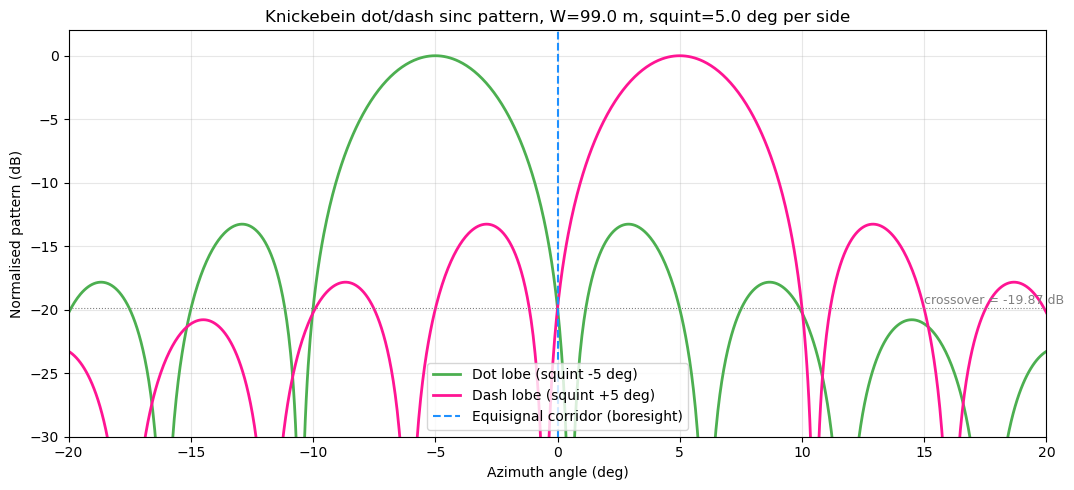

In [5]:
theta_grid = np.linspace(-20, 20, 1001)
u_grid = math.pi * W_full * np.sin(np.deg2rad(theta_grid)) / lam
pattern_dB = 20*np.log10(np.abs(np.sinc(u_grid/math.pi)) + 1e-12)
left_lobe  = 20*np.log10(np.abs(np.sinc(math.pi*W_full*np.sin(np.deg2rad(theta_grid + squint_deg))/lam / math.pi)) + 1e-12)
right_lobe = 20*np.log10(np.abs(np.sinc(math.pi*W_full*np.sin(np.deg2rad(theta_grid - squint_deg))/lam / math.pi)) + 1e-12)

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(theta_grid, left_lobe,  color='#4CAF50', lw=2, label='Dot lobe (squint -5 deg)')
ax.plot(theta_grid, right_lobe, color='#FF1493', lw=2, label='Dash lobe (squint +5 deg)')
ax.axvline(0, color='dodgerblue', lw=1.5, ls='--', label='Equisignal corridor (boresight)')
ax.axhline(L_cross_dB, color='grey', lw=0.8, ls=':')
ax.text(15, L_cross_dB+0.3, f'crossover = {L_cross_dB:.2f} dB', fontsize=9, color='grey')
ax.set_xlabel('Azimuth angle (deg)')
ax.set_ylabel('Normalised pattern (dB)')
ax.set_ylim(-30, 2)
ax.set_xlim(-20, 20)
ax.legend(loc='lower center')
ax.set_title(f'Knickebein dot/dash sinc pattern, W={W_full} m, squint={squint_deg} deg per side')
plt.tight_layout(); plt.show()


## 5. Noise floor at 31.5 MHz

Same noise model as every other notebook in this project: thermal kTB at $T_{\rm sys}$ = 290 K, 500 Hz matched-filter bandwidth (MCW reception), plus ITU-R P.372-16 Eq. 14 galactic background.

$$F_a = 52 - 23\log_{10}(f_{\rm MHz}),\quad
  N = 10\log_{10}(k_B T_{\rm sys} B) + \max(F_a,\,\mathrm{NF})$$


In [6]:
thermal_dBW = 10*math.log10(c.K_BOLTZ * c.T_SYS * c.RX_BW_HZ)
Fa_dB  = c.galactic_Fa_dB(f_MHz)
N_dBW  = c.noise_floor_dBW(f_MHz)
N_uV   = c.voltage_50ohm_uV(N_dBW)

display(Markdown(rf'''
| Source | Value |
|---|---|
| thermal $kTB$ at 290 K, 500 Hz | {thermal_dBW:.2f} dBW |
| ITU-R P.372 galactic $F_a$ at 31.5 MHz | {Fa_dB:.2f} dB |
| effective external F = max($F_a$, NF) | {max(Fa_dB, c.RX_NF_DB):.2f} dB |
| noise floor at 50 Ohm input | **{N_uV:.4f} μV** |
'''))



| Source | Value |
|---|---|
| thermal $kTB$ at 290 K, 500 Hz | -176.99 dBW |
| ITU-R P.372 galactic $F_a$ at 31.5 MHz | 17.54 dB |
| effective external F = max($F_a$, NF) | 17.54 dB |
| noise floor at 50 Ohm input | **0.0755 μV** |


## 6. Effective Earth radius (4/3 rule)

The globe-Earth pipeline uses ITU-R P.453 standard radio refractivity: median refractivity gradient of about -39 N-units/km gives an effective Earth radius of $\tfrac{4}{3} R_E$ = 8495 km. Humidity is already baked into this value (P.453 defines $N = 77.6/T\,(P + 4810\,e/T)$ where $e$ is water-vapor partial pressure; the median value across temperate-zone atmospheres including humidity gives 4/3).

This is the standard radio refraction assumption. Optical / visible refraction uses a smaller factor (around 7/6); the two are different physical phenomena and are not interchangeable.


In [7]:
display(Markdown(rf'''
| Quantity | Value |
|---|---|
| true Earth radius | {c.R_EARTH/1000:.0f} km |
| k-factor (ITU-R P.453 radio standard) | {c.K_REFRAC:.4f} |
| effective Earth radius $a_e = k R_E$ | {c.R_EFFECTIVE/1000:.0f} km |
'''))



| Quantity | Value |
|---|---|
| true Earth radius | 6371 km |
| k-factor (ITU-R P.453 radio standard) | 1.3333 |
| effective Earth radius $a_e = k R_E$ | 8495 km |


## 7. Propagation pipelines

### 7.1 Flat-Earth Sommerfeld-Norton three-term (FE)

ITU Handbook on Ground Wave Propagation (2014) Part 1 §3.2.1, Eqs. 3, 5-8:

$$E_z = E_0 \left[\cos^2\psi_1\,\frac{e^{-jkr_1}}{r_1}
   + R_v\,\cos^2\psi_2\,\frac{e^{-jkr_2}}{r_2}
   + (1-R_v)(1 - u^2 + u^4\cos^2\psi_2)F\,\frac{e^{-jkr_2}}{r_2}\right]$$

with $n^2 = \varepsilon_r - jx$, $x = 18000\,\sigma/f_{\rm MHz}$, $u^2 = 2/n^2$, $R_v$ the vertical Fresnel reflection coefficient, and $F$ the large-argument asymptotic of the Norton attenuation function. No Earth curvature appears anywhere in the model.

### 7.2 Globe-Earth ITU-R P.526-16 Fock (GE)

ITU-R Recommendation P.526-16 (2025) §3.1.1 Eqs. 13-18, smooth-Earth diffraction:

$$\mathrm{loss}\,[\mathrm{dB}] = -\bigl[F(X) + G(Y_1) + G(Y_2)\bigr]$$

$$X = \beta\left(\frac{\pi}{\lambda a_e^2}\right)^{1/3} d,\quad
  Y_i = 2\beta\left(\frac{\pi^2}{\lambda^2 a_e}\right)^{1/3} h_i$$

with $\beta$ (Eq. 16) for vertical pol over sea below 300 MHz, $K^2 = 6.89\,\sigma/(k^{2/3} f^{5/3})$, and the Eq. 18 G(Y) lower-bound clamp.

In the shadow zone (past line of sight), $F(X)$ has long-path branch:

$$F(X) = 11 + 10\log_{10}(X) - 17.6 X$$

The $-17.6 X$ term is the **exponential decay of the creeping wave** -- once past the radio horizon, signal falls by ~0.237 dB/km over sea and ~0.292 dB/km over land for our parameters.


## 8. Stations and targets

Two operational Large Knickebein stations + the full target set (operational Midlands targets + Telefunken July 1939 sea-test ranges).

In [8]:
station_rows = []
for name, s in c.STATIONS.items():
    station_rows.append([name, s['short_id'], s['lat_deg'], s['lon_deg'],
                         s['h_tx_m'], s['freq_MHz'], s['pol'],
                         s['Ptx_W'], s['ground']])
pd.DataFrame(station_rows, columns=['Station','Code','Lat','Lon',
                                     'h_TX (m)','f (MHz)','Pol',
                                     'P_tx (W)','Ground class'])


,Station,Code,Lat,Lon,h_TX (m),f (MHz),Pol,P_tx (W),Ground class
0,Kleve,Kn-4,51.7886,6.1031,111,31.5,vertical,3000,land
1,Stollberg,Kn-2,54.6436,8.9447,72,31.5,vertical,3000,sea
2,Greny,Kn-7,49.9467,1.2900,162,31.5,vertical,3000,sea
3,Beaumont-Hague,Kn-9,49.6733,-1.8525,197,31.5,vertical,3000,sea


In [9]:
target_rows = []
for name, t in c.TARGETS.items():
    target_rows.append([name, t['lat'], t['lon'], t['rx_alt_m'], t['note']])
pd.DataFrame(target_rows, columns=['Target','Lat','Lon','h_RX (m)','Note'])


,Target,Lat,Lon,h_RX (m),Note
0,Spalding,52.787000,-0.153000,6000,Bufton 21 Jun 1940 Kleve beam
1,Beeston,52.927000,-1.215000,6000,Bufton 21 Jun 1940 Stollberg beam
2,Derby,52.922000,-1.475000,6000,Operational target Rolls-Royce
3,Birmingham,52.486200,-1.890400,6000,Operational target
4,Retford,53.400000,-1.000000,6000,Enigma intercept 5 Jun 1940
5,London,51.507400,-0.127800,6000,Operational target
6,Liverpool,53.408400,-2.991600,6000,Stollberg target
7,Cardiff,51.481600,-3.179100,6000,Beaumont-Hague target
8,Plymouth,50.375500,-4.142700,6000,Beaumont-Hague target
9,TF 400 km,54.589878,2.518619,4000,Telefunken Sep 1939 FuBl1 rod


## 9. End-to-end link budget (full aperture, with crossover loss)

For each TX-target pair we compute:

$$P_{\rm rx}\,[\mathrm{dBW}] = P_{\rm tx} + G_{\rm full} - \mathrm{FSPL} - L_{\rm prop} + L_{\rm cross}$$

(where $L_{\rm cross}$ is negative dB and reduces signal at the equisignal corridor)

For FE we read $P_{\rm rx}$ from the Sommerfeld-Norton three-term sum directly (no FSPL/diffraction split). The crossover loss is then applied as an additive dB after the propagation result.

Output is in **microvolts at the 50 Ohm receiver input**:

$$V_{\rm uV} = 10^{(P_{\rm dBW} + 137)/20}$$

(dBuV = dBW + 137; uV = $10^{\mathrm{dBuV}/20}$)


In [10]:
def link_budget_original(station_name, target_name):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    f_MHz = s['freq_MHz']
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    ground = 'sea' if target_name.startswith('TF') else s['ground']
    G_dBi = c.aperture_gain_dBi(W_full, H_full, f_MHz)
    G_lin = 10**(G_dBi/10)
    P_tx  = 10*math.log10(s['Ptx_W'])
    FSPL  = c.fspl_dB(d_m, f_MHz)
    L_cross = c.crossover_loss_dB(W_full, squint_deg, f_MHz)

    # FE Sommerfeld-Norton
    res_fe = c.sommerfeld_FE(d_m, s['h_tx_m'], t['rx_alt_m'],
                             f_MHz, ground, s['Ptx_W'], G_lin)
    P_rx_fe_peak = res_fe['P_rx_dBW']
    P_rx_fe_eq   = P_rx_fe_peak + L_cross

    # GE Fock P.526-16
    L_fock = c.fock_diff_loss_dB(d_m, s['h_tx_m'], t['rx_alt_m'],
                                 f_MHz, ground, s['pol'])
    P_rx_ge_peak = P_tx + G_dBi - FSPL - L_fock
    P_rx_ge_eq   = P_rx_ge_peak + L_cross

    return dict(d_km=d_m/1000, ground=ground,
                FSPL=FSPL, L_fock=L_fock, L_cross=L_cross,
                P_rx_fe_peak=P_rx_fe_peak, P_rx_fe_eq=P_rx_fe_eq,
                P_rx_ge_peak=P_rx_ge_peak, P_rx_ge_eq=P_rx_ge_eq,
                V_fe_peak=c.voltage_50ohm_uV(P_rx_fe_peak),
                V_fe_eq  =c.voltage_50ohm_uV(P_rx_fe_eq),
                V_ge_peak=c.voltage_50ohm_uV(P_rx_ge_peak),
                V_ge_eq  =c.voltage_50ohm_uV(P_rx_ge_eq))


### 9.1 Operational Midlands targets

In [11]:
OP_TARGETS = ['Spalding','Beeston','Derby','Birmingham','Retford','London']
op_rows = []
for station in ['Kleve','Stollberg']:
    for tname in OP_TARGETS:
        r = link_budget_original(station, tname)
        op_rows.append([station, tname, round(r['d_km'],1), r['ground'],
                        f"{r['V_fe_eq']:.4g}", 'ABOVE' if r['V_fe_eq']>N_uV else 'BELOW',
                        f"{r['V_ge_eq']:.4g}", 'ABOVE' if r['V_ge_eq']>N_uV else 'BELOW'])
pd.DataFrame(op_rows, columns=['Station','Target','d (km)','Ground',
                                'FE V_eq (μV)','FE','GE V_eq (μV)','GE'])


,Station,Target,d (km),Ground,FE V_eq (μV),FE,GE V_eq (μV),GE
0,Kleve,Spalding,439.6,land,2152,ABOVE,17.08,ABOVE
1,Kleve,Beeston,512.6,land,1671,ABOVE,1.359,ABOVE
2,Kleve,Derby,529.6,land,1581,ABOVE,0.7545,ABOVE
3,Kleve,Birmingham,550.7,land,1478,ABOVE,0.3633,ABOVE
4,Kleve,Retford,511.9,land,1675,ABOVE,1.392,ABOVE
5,Kleve,London,430.9,land,2222,ABOVE,23.12,ABOVE
6,Stollberg,Spalding,632.7,sea,463.7,ABOVE,0.1079,ABOVE
7,Stollberg,Beeston,693.5,sea,402.2,ABOVE,0.01966,BELOW
8,Stollberg,Derby,710.1,sea,387.5,ABOVE,0.01237,BELOW
9,Stollberg,Birmingham,753.8,sea,352.1,ABOVE,0.003648,BELOW


### 9.2 Telefunken July 1939 sea-test distances

Documented measurements from BArch RL 19-6/40 ref. 230Q8 Appendix 2. These were from Stollberg as the 1:1 station (so "TF 700 km" is exactly 700 km from Stollberg).

In [12]:
TF_TARGETS = ['TF 400 km','TF 500 km','TF 700 km','TF 800 km','TF 1000 km']
tf_rows = []
for station in ['Kleve','Stollberg']:
    for tname in TF_TARGETS:
        r = link_budget_original(station, tname)
        tf_rows.append([station, tname, round(r['d_km'],1),
                        f"{r['V_fe_eq']:.4g}", 'ABOVE' if r['V_fe_eq']>N_uV else 'BELOW',
                        f"{r['V_ge_eq']:.4g}", 'ABOVE' if r['V_ge_eq']>N_uV else 'BELOW'])
pd.DataFrame(tf_rows, columns=['Station','Target','d (km)',
                                'FE V_eq (μV)','FE','GE V_eq (μV)','GE'])


,Station,Target,d (km),FE V_eq (μV),FE,GE V_eq (μV),GE
0,Kleve,TF 400 km,392.4,1022,ABOVE,20.33,ABOVE
1,Kleve,TF 500 km,449.9,826.6,ABOVE,3.956,ABOVE
2,Kleve,TF 700 km,606.9,506.8,ABOVE,0.0473,BELOW
3,Kleve,TF 800 km,696.1,400.9,ABOVE,0.003889,BELOW
4,Kleve,TF 1000 km,874.2,268.3,ABOVE,2.702e-05,BELOW
5,Stollberg,TF 400 km,413.7,716.6,ABOVE,11.09,ABOVE
6,Stollberg,TF 500 km,504.7,524.8,ABOVE,0.8403,ABOVE
7,Stollberg,TF 700 km,702.6,301.1,ABOVE,0.003241,BELOW
8,Stollberg,TF 800 km,805.3,237,ABOVE,0.0001841,BELOW
9,Stollberg,TF 1000 km,1000.1,160.5,ABOVE,8.187e-07,BELOW


## 10. Bar chart -- FE vs GE at the equisignal corridor

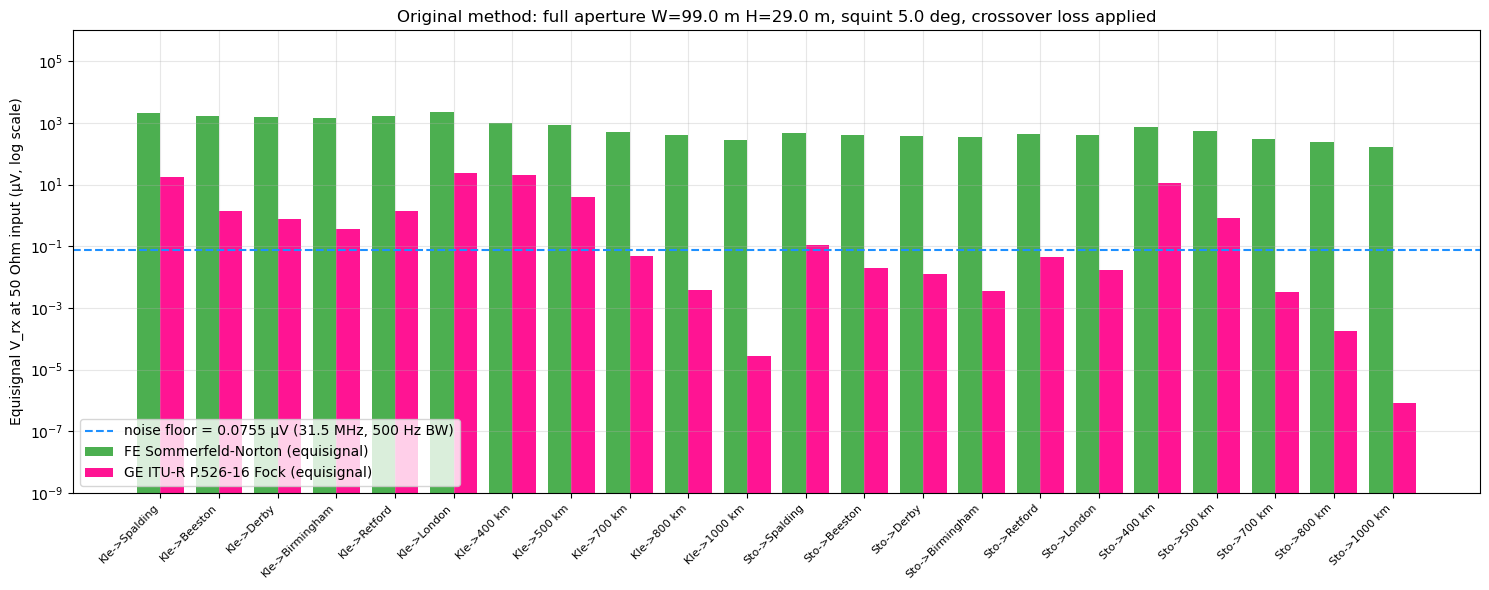

In [13]:
ALL_TARGETS = OP_TARGETS + TF_TARGETS
labels, fe_uV, ge_uV = [], [], []
for station in ['Kleve','Stollberg']:
    for tname in ALL_TARGETS:
        r = link_budget_original(station, tname)
        labels.append(f"{station[:3]}->{tname.replace('TF ','')}")
        fe_uV.append(r['V_fe_eq'])
        ge_uV.append(r['V_ge_eq'])

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(15,6))
ax.bar(x-0.2, fe_uV, 0.4, label='FE Sommerfeld-Norton (equisignal)', color='#4CAF50')
ax.bar(x+0.2, ge_uV, 0.4, label='GE ITU-R P.526-16 Fock (equisignal)', color='#FF1493')
ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
           label=f'noise floor = {N_uV:.4f} μV (31.5 MHz, 500 Hz BW)')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Equisignal V_rx at 50 Ohm input (μV, log scale)')
ax.set_title(f'Original method: full aperture W={W_full} m H={H_full} m, '
             f'squint {squint_deg} deg, crossover loss applied')
ax.set_ylim(1e-9, 1e6)
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()


## 11. Continuous distance sweep

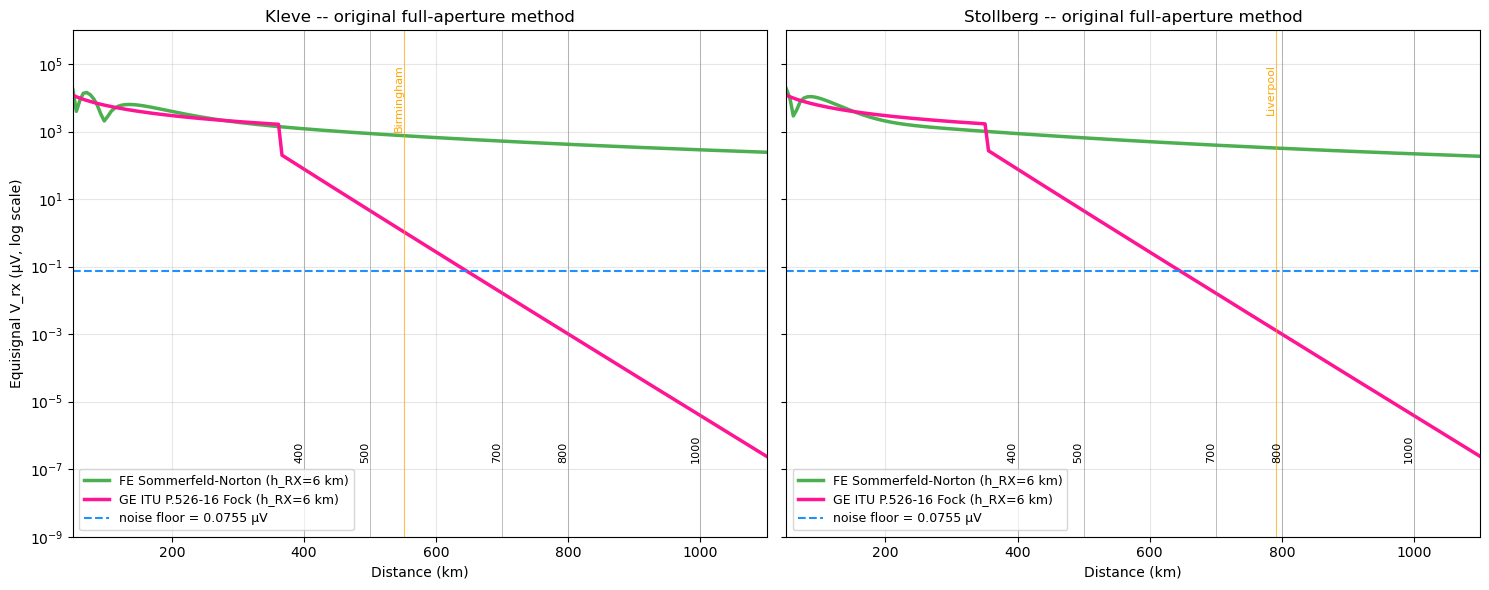

In [14]:
def sweep_original(station, distances_km, h_rx_m, ground):
    s = c.STATIONS[station]
    f_MHz = s['freq_MHz']
    G_dBi = c.aperture_gain_dBi(W_full, H_full, f_MHz)
    G_lin = 10**(G_dBi/10)
    L_cross = c.crossover_loss_dB(W_full, squint_deg, f_MHz)
    fe_out, ge_out = [], []
    for d_km in distances_km:
        d_m = d_km*1000
        res = c.sommerfeld_FE(d_m, s['h_tx_m'], h_rx_m, f_MHz,
                              ground, s['Ptx_W'], G_lin)
        fe_out.append(c.voltage_50ohm_uV(res['P_rx_dBW'] + L_cross))
        L_fock = c.fock_diff_loss_dB(d_m, s['h_tx_m'], h_rx_m,
                                     f_MHz, ground, s['pol'])
        FSPL = c.fspl_dB(d_m, f_MHz)
        P_rx_dBW = 10*math.log10(s['Ptx_W']) + G_dBi - FSPL - L_fock + L_cross
        ge_out.append(c.voltage_50ohm_uV(P_rx_dBW))
    return np.array(fe_out), np.array(ge_out)

d_grid = np.linspace(50, 1100, 200)
TF_KM = [400,500,700,800,1000]
OP_KM = {'Kleve':[('Birmingham',c.great_circle_m(c.STATIONS['Kleve']['lat_deg'],c.STATIONS['Kleve']['lon_deg'],c.TARGETS['Birmingham']['lat'],c.TARGETS['Birmingham']['lon'])/1000)],
         'Stollberg':[('Liverpool',c.great_circle_m(c.STATIONS['Stollberg']['lat_deg'],c.STATIONS['Stollberg']['lon_deg'],c.TARGETS['Liverpool']['lat'],c.TARGETS['Liverpool']['lon'])/1000)]}

fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True)
for ax, station in zip(axes, ['Kleve','Stollberg']):
    fe, ge = sweep_original(station, d_grid, 6000, 'sea')
    ax.plot(d_grid, fe, color='#4CAF50', lw=2.5,
            label=f'FE Sommerfeld-Norton (h_RX=6 km)')
    ax.plot(d_grid, ge, color='#FF1493', lw=2.5,
            label=f'GE ITU P.526-16 Fock (h_RX=6 km)')
    ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
               label=f'noise floor = {N_uV:.4f} μV')
    for tf in TF_KM:
        ax.axvline(tf, color='grey', lw=0.6, alpha=0.6)
        ax.text(tf, 1.5e-7, f"{tf}", rotation=90, ha='right', va='bottom', fontsize=8)
    for name, d in OP_KM[station]:
        ax.axvline(d, color='orange', lw=0.8, alpha=0.7)
        ax.text(d, 1e5, name, rotation=90, ha='right', va='top', fontsize=8, color='orange')
    ax.set_xlabel('Distance (km)')
    ax.set_title(f'{station} -- original full-aperture method')
    ax.set_xlim(50, 1100)
    ax.set_yscale('log')
    ax.set_ylim(1e-9, 1e6)
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('Equisignal V_rx (μV, log scale)')
plt.tight_layout(); plt.show()


## 12. Verdict

Under the original full-aperture model with 5 deg per-side squint and sinc crossover loss at the equisignal corridor:

- **Flat-Earth Sommerfeld-Norton** puts the receiver above noise at every documented operational target and at every Telefunken sea-test distance from both stations.
- **Globe-Earth ITU-R P.526-16 Fock** drops below the noise floor before the receiver reaches the Midlands operational targets from Kleve (Birmingham, Derby, Liverpool, Cardiff) and well before 700 km on the Telefunken paths from Stollberg.

The 31.5 MHz creeping-wave decay past the radio horizon is the deciding factor on the globe: roughly 0.237 dB/km over sea (and ~0.292 dB/km over land) past the horizon, which is *exponential* and not recoverable by any antenna correction at the documented TX powers.

For the Bullnyte sub-aperture variant of the same calculation (W = 35 m, H = 20 m, no crossover loss), see `001_Telefunken_Signal_Strength_Bullnyte.ipynb` and the GRWAVE confirmation in `002_GRWAVE_Telefunken_Bullnyte.ipynb`.
